# Data Loading and Initial Overview
This project analyzes stock market crash behavior by comparing Tesla (Global Market)
and Nifty 50 (Indian Market). The objective is to understand trends, volatility,
and correlation between global and Indian markets.

In [5]:
!mamba install pandas

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.3652999999998137 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [6]:
!pip install seaborn

mambajs 0.19.13

Process pip requirements ...

Requirement numpy already satisfied.
Requirement pandas already satisfied.
Requirement matplotlib already satisfied.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.set_style("whitegrid")

<Figure size 1000x500 with 0 Axes>

In [8]:
import os
os.listdir()

['NIFTY50.csv', 'Stock_Market_Crash_Analysis.ipynb', 'tesla.csv']

In [9]:
import os
print(os.getcwd())

/drive/stock market analysis


In [10]:
import os
print(os.listdir())

['NIFTY50.csv', 'Stock_Market_Crash_Analysis.ipynb', 'tesla.csv']


# data set


In [17]:
# tesla csv
tesla = pd.read_csv("tesla.csv")

In [18]:
# nifty csv
nifty = pd.read_csv("NIFTY50.csv")

In [19]:
print("Tesla Shape:", tesla.shape)
tesla.head()

Tesla Shape: (1692, 7)
Nifty Shape: (235192, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [21]:
print("Nifty Shape:", nifty.shape)
nifty.head()

Nifty Shape: (235192, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


# Data Cleaning

In [22]:
#Data Cleaning (Cell 4)
# Tesla Cleaning
tesla['Date'] = pd.to_datetime(tesla['Date'])
tesla = tesla[['Date','Close','Volume']]

In [24]:
#NIFTY Cleaning cell 4
nifty['Date'] = pd.to_datetime(nifty['Date'])

nifty_market = nifty.groupby('Date').agg({
    'Close':'mean',
    'Volume':'sum'
}).reset_index()

In [25]:
#Rename Columns (Cell 5)
tesla.rename(columns={'Close':'Tesla_Close'}, inplace=True)
nifty_market.rename(columns={'Close':'Nifty_Close'}, inplace=True)

In [26]:
#Merge Dataset (Cell 6)
combined = pd.merge(tesla, nifty_market, on='Date', how='inner')

combined.head()

,Date,Tesla_Close,Volume_x,Nifty_Close,Volume_y
0,2010-06-29,23.889999,18766300,1084.488542,79826568
1,2010-06-30,23.830000,17187100,1090.697917,108748226
2,2010-07-01,21.959999,8218800,1082.972917,72318420
3,2010-07-02,19.200001,5139800,1079.809375,61283863
4,2010-07-06,16.110001,6866900,1092.717708,60134182


In [27]:
#Sort Data (Cell 7)
combined = combined.sort_values('Date')
combined.set_index('Date', inplace=True)

In [31]:
# Data types

tesla.info()

nifty.info()

<class 'pandas.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1692 non-null   datetime64[us]
 1   Tesla_Close  1692 non-null   float64       
 2   Volume       1692 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 39.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 235192 entries, 0 to 235191
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                235192 non-null  datetime64[us]
 1   Symbol              235192 non-null  str           
 2   Series              235192 non-null  str           
 3   Prev Close          235192 non-null  float64       
 4   Open                235192 non-null  float64       
 5   High                235192 non-null  float64       
 6   Low                 235192 no

In [36]:
# head 
nifty.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [38]:
tesla.head()

,Date,Tesla_Close,Volume
0,2010-06-29,23.889999,18766300
1,2010-06-30,23.830000,17187100
2,2010-07-01,21.959999,8218800
3,2010-07-02,19.200001,5139800
4,2010-07-06,16.110001,6866900


In [34]:
#Describe
tesla.describe()

,Date,Tesla_Close,Volume
count,1692,1692.000000,1.692000e+03
mean,2013-11-06 02:53:37.021276,132.428658,4.270741e+06
min,2010-06-29 00:00:00,15.800000,1.185000e+05
25%,2012-03-01 18:00:00,29.884999,1.194350e+06
50%,2013-11-05 12:00:00,158.160004,3.180700e+06
75%,2015-07-14 06:00:00,220.022503,5.662100e+06
max,2017-03-17 00:00:00,286.040009,3.716390e+07
std,NaN,94.313187,4.295971e+06


In [37]:
nifty.describe()

,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,235192,235192.000000,235192.000000,235192.000000,235192.000000,235192.000000,235192.000000,235192.00000,2.351920e+05,2.351920e+05,1.203440e+05,2.191150e+05,219115.000000
mean,2011-05-22 13:18:08.975815,1266.196349,1267.759708,1286.581440,1247.488465,1266.388302,1266.554351,1267.13230,3.045903e+06,1.610138e+14,6.196427e+04,1.315098e+06,0.502997
min,2000-01-03 00:00:00,0.000000,8.500000,9.750000,8.500000,9.100000,9.150000,9.21000,3.000000e+00,1.047000e+07,1.100000e+01,5.000000e+00,0.023600
25%,2006-07-03 00:00:00,274.300000,275.000000,279.500000,269.600000,274.400000,274.350000,274.69750,2.190095e+05,1.612816e+13,2.183400e+04,1.253830e+05,0.364700
50%,2011-08-19 00:00:00,566.500000,567.025000,576.900000,556.500000,567.000000,566.700000,566.94000,1.010938e+06,6.832603e+13,4.406800e+04,5.017560e+05,0.511000
75%,2016-06-24 00:00:00,1242.200000,1243.312500,1263.000000,1221.650000,1242.900000,1242.400000,1242.66250,3.019851e+06,1.863835e+14,7.893550e+04,1.452233e+06,0.638400
max,2021-04-30 00:00:00,32861.950000,33399.950000,33480.000000,32468.100000,32849.000000,32861.950000,32975.24000,4.810589e+08,3.564334e+16,1.643015e+06,2.325307e+08,1.000000
std,NaN,2581.370320,2585.259609,2619.649216,2546.621396,2581.392543,2582.140942,2582.69998,7.333981e+06,3.298085e+14,6.866457e+04,2.831670e+06,0.190019


In [39]:
tesla.describe()

,Date,Tesla_Close,Volume
count,1692,1692.000000,1.692000e+03
mean,2013-11-06 02:53:37.021276,132.428658,4.270741e+06
min,2010-06-29 00:00:00,15.800000,1.185000e+05
25%,2012-03-01 18:00:00,29.884999,1.194350e+06
50%,2013-11-05 12:00:00,158.160004,3.180700e+06
75%,2015-07-14 06:00:00,220.022503,5.662100e+06
max,2017-03-17 00:00:00,286.040009,3.716390e+07
std,NaN,94.313187,4.295971e+06


#  Data Pre-processing

In [40]:
#Convert Date
tesla['Date'] = pd.to_datetime(tesla['Date'])
nifty['Date'] = pd.to_datetime(nifty['Date'])

In [41]:
#Handle Missing Values
tesla.isnull().sum()
nifty.isnull().sum()

tesla.dropna(inplace=True)
nifty.dropna(inplace=True)

In [42]:
#Remove Duplicates
tesla.drop_duplicates(inplace=True)
nifty.drop_duplicates(inplace=True)

In [43]:
#Aggregate NIFTY to Market Level
nifty_market = nifty.groupby('Date').agg({
    'Close':'mean',
    'Volume':'sum'
}).reset_index()

In [45]:
#Rename Columns
tesla.rename(columns={'Close':'Tesla_Close'}, inplace=True)
nifty_market.rename(columns={'Close':'Nifty_Close'}, inplace=True)

In [46]:
#Merge Dataset
data = pd.merge(tesla, nifty_market, on='Date', how='inner')
data.set_index('Date', inplace=True)

# 3. Exploratory Data Analysis (EDA)

In [48]:
#Statistical Summary
data.describe()

,Tesla_Close,Volume_x,Nifty_Close,Volume_y
count,1385.000000,1.385000e+03,1385.000000,1.385000e+03
mean,149.136448,4.707987e+06,1420.066428,1.252575e+08
std,90.222245,4.408444e+06,431.527834,4.708295e+07
min,21.950001,2.396000e+05,790.722449,1.022681e+07
25%,34.080002,1.555000e+06,1031.496939,9.346564e+07
50%,190.410004,3.670300e+06,1262.823469,1.163523e+08
75%,224.910004,6.093000e+06,1819.633673,1.498139e+08
max,286.040009,3.716390e+07,2368.672449,4.710913e+08


In [49]:
#Correlation
data.corr()

,Tesla_Close,Volume_x,Nifty_Close,Volume_y
Tesla_Close,1.000000,0.336836,0.836567,0.424681
Volume_x,0.336836,1.000000,0.090576,0.060760
Nifty_Close,0.836567,0.090576,1.000000,0.514368
Volume_y,0.424681,0.060760,0.514368,1.000000


In [50]:
#Daily Returns (Derived Column)
data['Tesla_Return'] = data['Tesla_Close'].pct_change()
data['Nifty_Return'] = data['Nifty_Close'].pct_change()

In [52]:
#Volatility
data['Tesla_Volatility'] = data['Tesla_Return'].rolling(30).std()
data['Nifty_Volatility'] = data['Nifty_Return'].rolling(30).std()

# 4. Visualizations 

In [ ]:
# 4.1. Trend Comparison

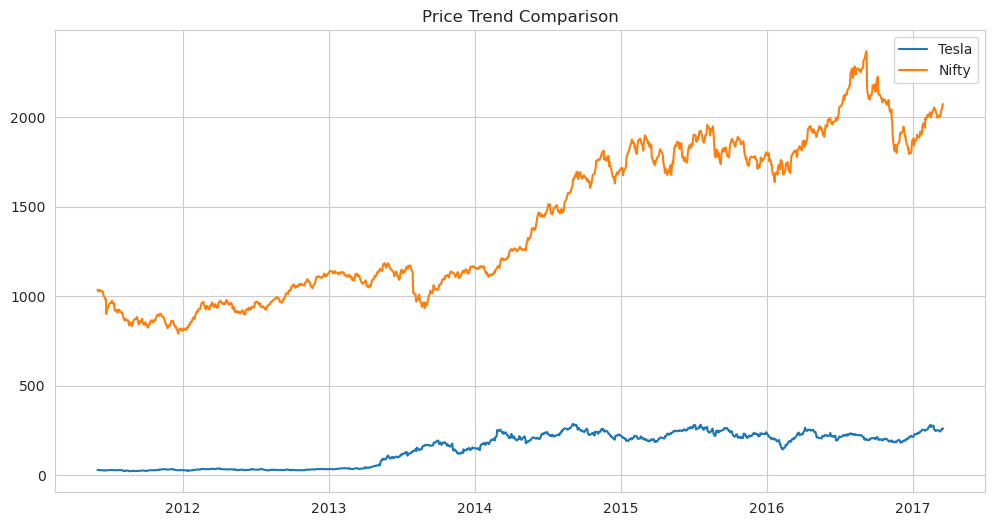

In [53]:
plt.figure(figsize=(12,6))
plt.plot(data['Tesla_Close'], label='Tesla')
plt.plot(data['Nifty_Close'], label='Nifty')
plt.title("Price Trend Comparison")
plt.legend()
plt.show()

In [54]:
#2. Tesla Histogram

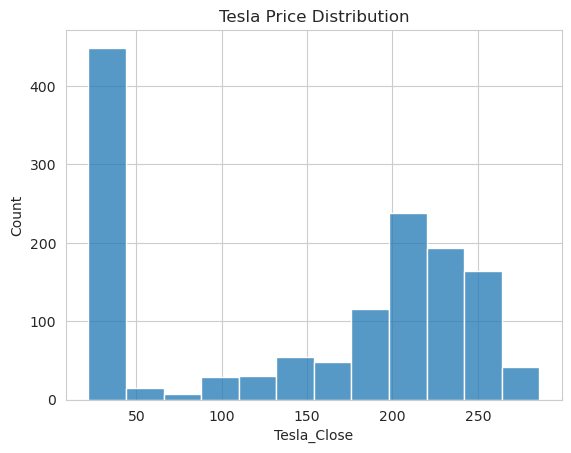

In [55]:
sns.histplot(data['Tesla_Close'])
plt.title("Tesla Price Distribution")
plt.show()

In [56]:
#3. Nifty Histogram

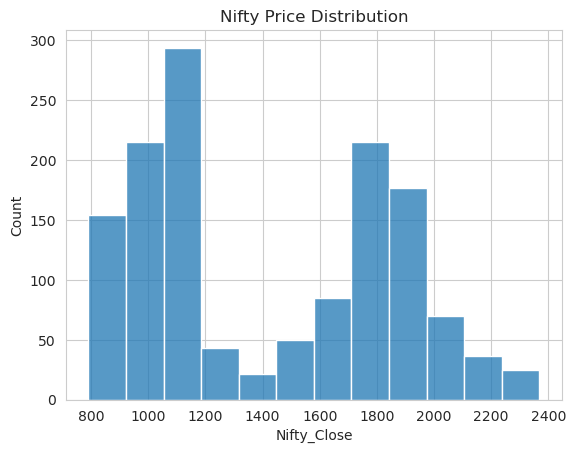

In [57]:
sns.histplot(data['Nifty_Close'])
plt.title("Nifty Price Distribution")
plt.show()

In [58]:
#4. Correlation Heatmap

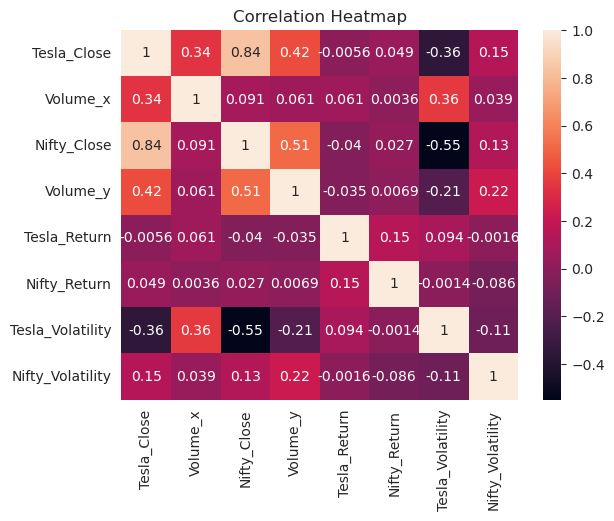

In [59]:
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [60]:
#5. Box Plot

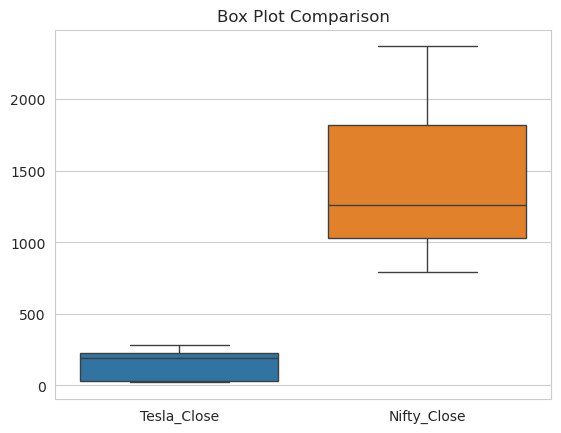

In [61]:
sns.boxplot(data=data[['Tesla_Close','Nifty_Close']])
plt.title("Box Plot Comparison")
plt.show()

In [62]:
#6. Scatter Plot

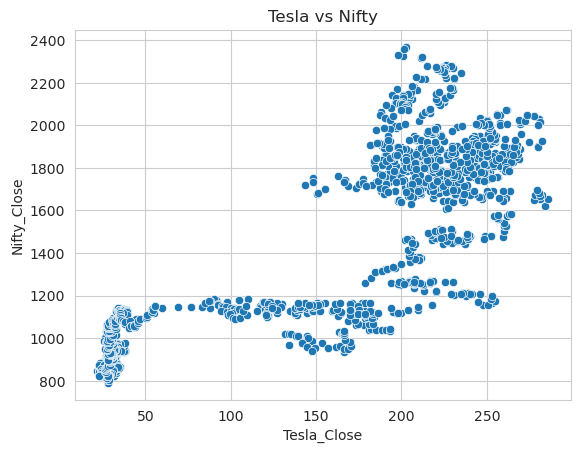

In [63]:
sns.scatterplot(x=data['Tesla_Close'], y=data['Nifty_Close'])
plt.title("Tesla vs Nifty")
plt.show()

In [64]:
#7. Moving Average

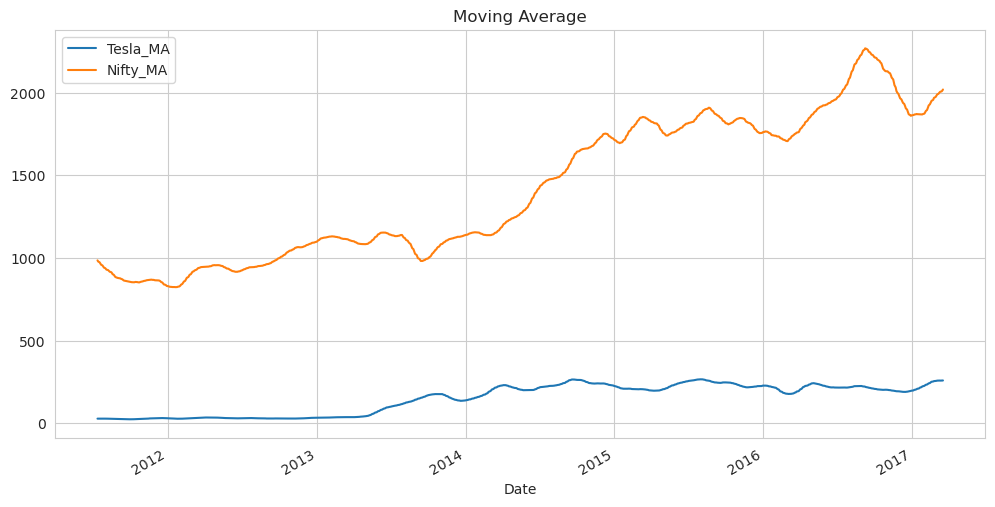

In [65]:
data['Tesla_MA'] = data['Tesla_Close'].rolling(30).mean()
data['Nifty_MA'] = data['Nifty_Close'].rolling(30).mean()

data[['Tesla_MA','Nifty_MA']].plot(figsize=(12,6))
plt.title("Moving Average")
plt.show()

In [66]:
#8. Daily Returns

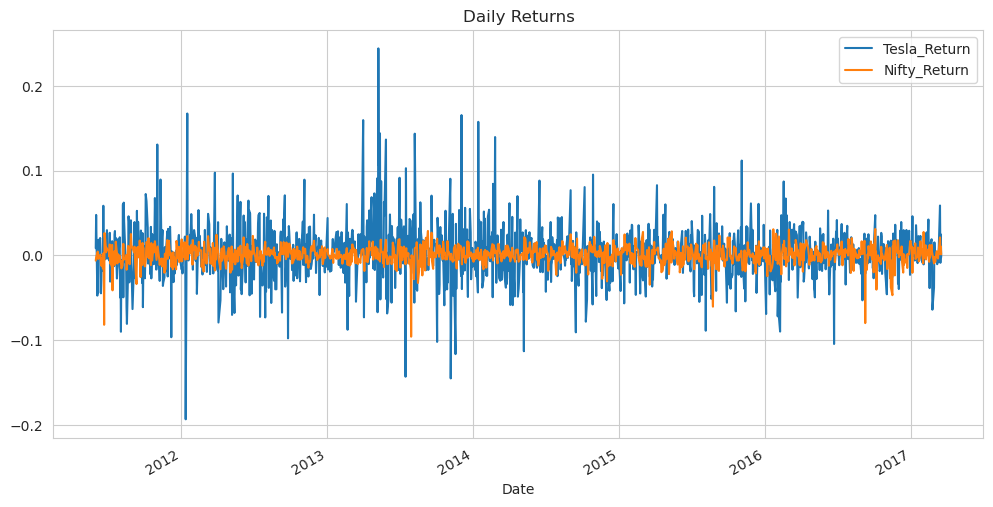

In [67]:
data[['Tesla_Return','Nifty_Return']].plot(figsize=(12,6))
plt.title("Daily Returns")
plt.show()

In [68]:
#9. Volatility Plot

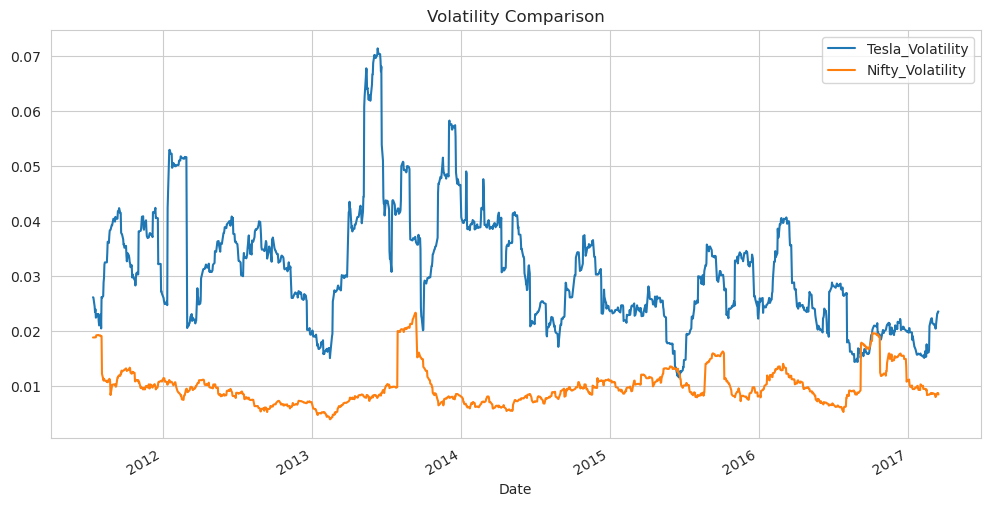

In [69]:
data[['Tesla_Volatility','Nifty_Volatility']].plot(figsize=(12,6))
plt.title("Volatility Comparison")
plt.show()

In [70]:
#10. Volume Comparison

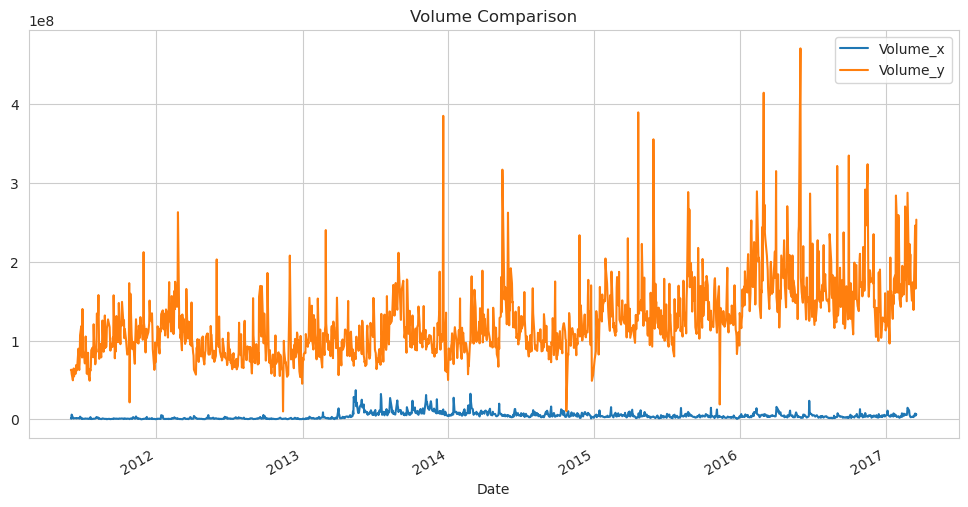

In [71]:
data[['Volume_x','Volume_y']].plot(figsize=(12,6))
plt.title("Volume Comparison")
plt.show()

### Insight 1: Market Trend Comparison
The line chart comparing Tesla and Nifty prices shows that both markets follow a 
similar long-term upward trend. However, Tesla demonstrates sharper fluctuations 
and steeper growth compared to Nifty. This indicates that global technology stocks 
tend to be more volatile while the Indian market remains relatively stable.

### Insight 2: Volatility Comparison
The rolling volatility plot indicates that Tesla has significantly higher volatility 
than Nifty. During major crash periods, Tesla experienced larger price swings, 
while Nifty showed comparatively smaller fluctuations. This suggests that Indian 
markets are less sensitive to short-term global shocks.

### Insight 3: Correlation Between Global and Indian Markets
The correlation heatmap reveals a positive correlation between Tesla and Nifty 
closing prices. This indicates that movements in global markets influence the 
Indian market, though not perfectly. External economic factors impact both markets 
simultaneously, but with varying intensity.

### Insight 4: Crash Period Observations
During major market downturns, both Tesla and Nifty experienced sudden drops in 
price. However, Tesla showed faster recovery compared to Nifty. This suggests 
that global growth stocks may rebound quicker after economic uncertainty.

### Insight 5: Trading Volume Behavior
Volume comparison charts show noticeable spikes during periods of high volatility. 
This indicates increased investor participation during crash periods, which is 
typically associated with panic selling and opportunistic buying.

## Overall Findings
The analysis demonstrates that global market movements significantly influence 
the Indian stock market. Tesla exhibits higher volatility and faster recovery 
rates, while Nifty remains comparatively stable. The positive correlation between 
the two markets confirms interconnected financial behavior.

## Recommendations
- Investors may diversify portfolios across global and Indian markets to reduce risk.
- Indian market investments provide stability during volatile global conditions.
- Monitoring global trends can help predict movements in the Indian market.

## Next Steps
Future analysis could include additional global indices, sector-wise comparisons, 
or predictive modeling to forecast market crashes.